In [1]:
# ============================================================
# PIPELINE COMPLETO TFM (VERSIÓN FINAL CON LOGGING)
# ============================================================


# ============================================================
# A: PREPARACIÓN
# ============================================================

# ------------------------------------------------------------
# A1. Configuración reproducible e imports
# ------------------------------------------------------------

import os
import random
import numpy as np
import pandas as pd
import GEOparse
import matplotlib.pyplot as plt
import time

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, RFE
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    recall_score,
    precision_score,
    balanced_accuracy_score,
    matthews_corrcoef
)

print("\n=== CONFIGURACIÓN ===")

# ------------------------------------------------------------
# Semilla global del experimento (REPRODUCIBILIDAD)
# ------------------------------------------------------------

RANDOM_STATE = 42
SEED = RANDOM_STATE

# Fijar semillas en todos los niveles posibles
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

# ------------------------------------------------------------
# Parámetros del experimento
# ------------------------------------------------------------

K_VALUES = [20, 50, 100]

print(f"Random state global: {RANDOM_STATE}")
print(f"Valores de K evaluados: {K_VALUES}")


# ------------------------------------------------------------
# A2. Carga dataset GSE55348
# ------------------------------------------------------------

print("\n=== CARGANDO GSE55348 ===")

gse = GEOparse.get_GEO("GSE55348", destdir="../data")

expr_data = {}

for gsm_name, gsm in gse.gsms.items():
    expr_data[gsm_name] = gsm.table.set_index("ID_REF")["VALUE"]

X = pd.DataFrame(expr_data).T

print("Shape X:", X.shape)


# ------------------------------------------------------------
# A3. Labels
# ------------------------------------------------------------

print("\n=== EXTRACCIÓN DE LABELS ===")

y = []

for gsm_name, gsm in gse.gsms.items():
    chars = gsm.metadata.get("characteristics_ch1", [])
    label = None

    for c in chars:
        c = c.lower()
        if "event:" in c:
            label = int(c.split(":")[-1].strip())

    if label is None:
        raise ValueError(f"No label en {gsm_name}")

    y.append(label)

y = np.array(y)

print("Distribución clases:", np.bincount(y))


# ------------------------------------------------------------
# A4. Log transform
# ------------------------------------------------------------

print("\n=== LOG TRANSFORM ===")

X_log = np.log2(X + 1)


# ------------------------------------------------------------
# A5. Configuración de validación cruzada
# ------------------------------------------------------------

print("\n=== CONFIGURANDO VALIDACIÓN CRUZADA ===")

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("StratifiedKFold configurado con shuffle=True y semilla fija")

06-May-2026 20:12:08 DEBUG utils - Directory ../data already exists. Skipping.
06-May-2026 20:12:08 INFO GEOparse - File already exist: using local version.
06-May-2026 20:12:08 INFO GEOparse - Parsing ../data\GSE55348_family.soft.gz: 
06-May-2026 20:12:08 DEBUG GEOparse - DATABASE: GeoMiame
06-May-2026 20:12:08 DEBUG GEOparse - SERIES: GSE55348
06-May-2026 20:12:08 DEBUG GEOparse - PLATFORM: GPL14951



=== CONFIGURACIÓN ===
Random state global: 42
Valores de K evaluados: [20, 50, 100]

=== CARGANDO GSE55348 ===


06-May-2026 20:12:09 DEBUG GEOparse - SAMPLE: GSM1334487
06-May-2026 20:12:09 DEBUG GEOparse - SAMPLE: GSM1334488
06-May-2026 20:12:09 DEBUG GEOparse - SAMPLE: GSM1334489
06-May-2026 20:12:09 DEBUG GEOparse - SAMPLE: GSM1334490
06-May-2026 20:12:09 DEBUG GEOparse - SAMPLE: GSM1334491
06-May-2026 20:12:09 DEBUG GEOparse - SAMPLE: GSM1334492
06-May-2026 20:12:09 DEBUG GEOparse - SAMPLE: GSM1334493
06-May-2026 20:12:09 DEBUG GEOparse - SAMPLE: GSM1334494
06-May-2026 20:12:10 DEBUG GEOparse - SAMPLE: GSM1334495
06-May-2026 20:12:10 DEBUG GEOparse - SAMPLE: GSM1334496
06-May-2026 20:12:10 DEBUG GEOparse - SAMPLE: GSM1334497
06-May-2026 20:12:10 DEBUG GEOparse - SAMPLE: GSM1334498
06-May-2026 20:12:10 DEBUG GEOparse - SAMPLE: GSM1334499
06-May-2026 20:12:10 DEBUG GEOparse - SAMPLE: GSM1334500
06-May-2026 20:12:10 DEBUG GEOparse - SAMPLE: GSM1334501
06-May-2026 20:12:10 DEBUG GEOparse - SAMPLE: GSM1334502
06-May-2026 20:12:10 DEBUG GEOparse - SAMPLE: GSM1334503
06-May-2026 20:12:10 DEBUG GEOp

Shape X: (53, 29377)

=== EXTRACCIÓN DE LABELS ===
Distribución clases: [30 23]

=== LOG TRANSFORM ===

=== CONFIGURANDO VALIDACIÓN CRUZADA ===
StratifiedKFold configurado con shuffle=True y semilla fija


In [2]:
# ============================================================
# B: EXPERIMENTACIÓN COMPLETA
# Evaluación interna mediante validación cruzada estratificada
# Incluye métricas predictivas, métricas clínicas y matriz de confusión
# ============================================================

from sklearn.model_selection import cross_validate, cross_val_predict, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, mutual_info_classif, RFE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    recall_score,
    precision_score,
    balanced_accuracy_score,
    matthews_corrcoef
)

import numpy as np
import pandas as pd
import time


# ============================================================
# CONFIGURACIÓN DE VALIDACIÓN CRUZADA
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

all_results = []

total_start = time.time()

print("\n" + "=" * 60)
print("=== EXPERIMENTO K ===")
print("=" * 60)

total_models = len(K_VALUES) * 4
model_counter = 0


# ============================================================
# EXPERIMENTO K
# ============================================================

for K in K_VALUES:

    print("\n" + "=" * 60)
    print(f"Evaluando K = {K}")
    print("=" * 60)

    pipelines = {
        "LR baseline": Pipeline([
            ("variance", VarianceThreshold(0.01)),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000))
        ]),

        "LR + ANOVA": Pipeline([
            ("variance", VarianceThreshold(0.01)),
            ("scaler", StandardScaler()),
            ("select", SelectKBest(score_func=f_classif, k=K)),
            ("model", LogisticRegression(max_iter=1000))
        ]),

        "LR + MutualInfo": Pipeline([
            ("variance", VarianceThreshold(0.01)),
            ("scaler", StandardScaler()),
            ("select", SelectKBest(
                score_func=lambda X, y: mutual_info_classif(
                    X,
                    y,
                    random_state=RANDOM_STATE
                ),
                k=K
            )),
            ("model", LogisticRegression(max_iter=1000))
        ]),

        "LR + RFE": Pipeline([
            ("variance", VarianceThreshold(0.01)),
            ("scaler", StandardScaler()),
            ("select", RFE(
                estimator=LogisticRegression(max_iter=1000),
                n_features_to_select=K,
                step=50
            )),
            ("model", LogisticRegression(max_iter=1000))
        ])
    }

    for name, pipe in pipelines.items():

        model_counter += 1

        print(f"\n[{model_counter}/{total_models}] Modelo: {name} | K={K}")

        start = time.time()

        print("  - Ejecutando cross-validation...")

        scores = cross_validate(
            estimator=pipe,
            X=X_log,
            y=y,
            cv=cv,
            scoring={
                "roc_auc": "roc_auc",
                "f1": "f1",
                "accuracy": "accuracy"
            },
            n_jobs=2
        )

        auc_mean = np.mean(scores["test_roc_auc"])
        auc_std = np.std(scores["test_roc_auc"])

        print(f"  - CV terminado. AUC medio: {auc_mean:.4f} ± {auc_std:.4f}")

        print("  - Calculando predicciones out-of-fold...")

        y_pred = cross_val_predict(
            estimator=pipe,
            X=X_log,
            y=y,
            cv=cv,
            n_jobs=2
        )

        tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        precision = precision_score(y, y_pred, zero_division=0)
        recall = recall_score(y, y_pred, zero_division=0)
        balanced_acc = balanced_accuracy_score(y, y_pred)
        mcc = matthews_corrcoef(y, y_pred)

        end = time.time()
        elapsed = end - start

        print(
            f"  - OOF terminado | "
            f"Sens: {sensitivity:.3f} | "
            f"Spec: {specificity:.3f} | "
            f"MCC: {mcc:.3f} | "
            f"Tiempo: {elapsed:.1f} s"
        )

        all_results.append({
            "Model": name,
            "K": K,
            "ROC-AUC": auc_mean,
            "ROC-AUC std": auc_std,
            "F1": np.mean(scores["test_f1"]),
            "Accuracy": np.mean(scores["test_accuracy"]),
            "Sensitivity": sensitivity,
            "Specificity": specificity,
            "Precision": precision,
            "Recall": recall,
            "Balanced Acc": balanced_acc,
            "MCC": mcc,
            "TP": tp,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "Time (s)": elapsed
        })


# ============================================================
# B2: EXPERIMENTO CON REGULARIZACIÓN L1
# ============================================================

print("\n" + "=" * 60)
print("=== EXPERIMENTO L1 ===")
print("=" * 60)

C_VALUES = [0.01, 0.1, 1]
l1_results = []

for i, C in enumerate(C_VALUES, start=1):

    print("\n" + "-" * 60)
    print(f"[L1 {i}/{len(C_VALUES)}] Evaluando C = {C}")
    print("-" * 60)

    start = time.time()

    pipe = Pipeline([
        ("variance", VarianceThreshold(0.01)),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            penalty="l1",
            solver="saga",
            C=C,
            max_iter=5000,
            random_state=RANDOM_STATE
        ))
    ])

    print("  - Ejecutando cross-validation...")

    scores = cross_validate(
        estimator=pipe,
        X=X_log,
        y=y,
        cv=cv,
        scoring={
            "roc_auc": "roc_auc",
            "f1": "f1",
            "accuracy": "accuracy"
        },
        n_jobs=2
    )

    auc_mean = np.mean(scores["test_roc_auc"])
    auc_std = np.std(scores["test_roc_auc"])

    print(f"  - CV terminado. AUC medio: {auc_mean:.4f} ± {auc_std:.4f}")

    print("  - Calculando predicciones out-of-fold...")

    y_pred = cross_val_predict(
        estimator=pipe,
        X=X_log,
        y=y,
        cv=cv,
        n_jobs=2
    )

    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision = precision_score(y, y_pred, zero_division=0)
    recall = recall_score(y, y_pred, zero_division=0)
    balanced_acc = balanced_accuracy_score(y, y_pred)
    mcc = matthews_corrcoef(y, y_pred)

    end = time.time()
    elapsed = end - start

    print(
        f"  - OOF terminado | "
        f"Sens: {sensitivity:.3f} | "
        f"Spec: {specificity:.3f} | "
        f"MCC: {mcc:.3f} | "
        f"Tiempo: {elapsed:.1f} s"
    )

    l1_results.append({
        "Model": "LR L1",
        "C": C,
        "ROC-AUC": auc_mean,
        "ROC-AUC std": auc_std,
        "F1": np.mean(scores["test_f1"]),
        "Accuracy": np.mean(scores["test_accuracy"]),
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Precision": precision,
        "Recall": recall,
        "Balanced Acc": balanced_acc,
        "MCC": mcc,
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "Time (s)": elapsed
    })


# ============================================================
# TABLAS FINALES
# ============================================================

results_df = pd.DataFrame(all_results)
l1_results_df = pd.DataFrame(l1_results)

results_df = results_df.sort_values(
    by=["ROC-AUC", "MCC"],
    ascending=False
).reset_index(drop=True)

l1_results_df = l1_results_df.sort_values(
    by=["ROC-AUC", "MCC"],
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 60)
print("=== RESULTADOS EXPERIMENTO K ===")
print("=" * 60)
display(results_df)

print("\n" + "=" * 60)
print("=== RESULTADOS L1 ===")
print("=" * 60)
display(l1_results_df)

total_end = time.time()
total_elapsed = total_end - total_start

print("\n" + "=" * 60)
print(f"Tiempo total experimentación: {total_elapsed / 60:.2f} min")
print("=" * 60)


=== EXPERIMENTO K ===

Evaluando K = 20

[1/12] Modelo: LR baseline | K=20
  - Ejecutando cross-validation...
  - CV terminado. AUC medio: 0.7900 ± 0.1569
  - Calculando predicciones out-of-fold...
  - OOF terminado | Sens: 0.696 | Spec: 0.700 | MCC: 0.393 | Tiempo: 5.9 s

[2/12] Modelo: LR + ANOVA | K=20
  - Ejecutando cross-validation...
  - CV terminado. AUC medio: 0.8967 ± 0.1137
  - Calculando predicciones out-of-fold...
  - OOF terminado | Sens: 0.826 | Spec: 0.833 | MCC: 0.657 | Tiempo: 3.9 s

[3/12] Modelo: LR + MutualInfo | K=20
  - Ejecutando cross-validation...
  - CV terminado. AUC medio: 0.9033 ± 0.0670
  - Calculando predicciones out-of-fold...
  - OOF terminado | Sens: 0.739 | Spec: 0.767 | MCC: 0.504 | Tiempo: 236.4 s

[4/12] Modelo: LR + RFE | K=20
  - Ejecutando cross-validation...
  - CV terminado. AUC medio: 0.7983 ± 0.0901
  - Calculando predicciones out-of-fold...
  - OOF terminado | Sens: 0.609 | Spec: 0.800 | MCC: 0.418 | Tiempo: 241.1 s

Evaluando K = 50

[5/1

,Model,K,ROC-AUC,ROC-AUC std,F1,Accuracy,Sensitivity,Specificity,Precision,Recall,Balanced Acc,MCC,TP,TN,FP,FN,Time (s)
0,LR + MutualInfo,20,0.903333,0.066999,0.727778,0.754545,0.739130,0.766667,0.708333,0.739130,0.752899,0.503612,17,23,7,6,236.446182
1,LR + ANOVA,20,0.896667,0.113725,0.822222,0.829091,0.826087,0.833333,0.791667,0.826087,0.829710,0.656572,19,25,5,4,3.850197
2,LR + ANOVA,50,0.860000,0.123648,0.733333,0.756364,0.739130,0.766667,0.708333,0.739130,0.752899,0.503612,17,23,7,6,3.614005
3,LR + MutualInfo,50,0.855000,0.102144,0.694488,0.734545,0.695652,0.766667,0.695652,0.695652,0.731159,0.462319,16,23,7,7,238.642556
4,LR + ANOVA,100,0.831667,0.143798,0.644444,0.678182,0.652174,0.700000,0.625000,0.652174,0.676087,0.350653,15,21,9,8,3.387236
5,LR + MutualInfo,100,0.825000,0.131445,0.696869,0.734545,0.695652,0.766667,0.695652,0.695652,0.731159,0.462319,16,23,7,7,234.270360
6,LR + RFE,50,0.816667,0.144530,0.620000,0.658182,0.652174,0.666667,0.600000,0.652174,0.659420,0.316555,15,20,10,8,234.982060
7,LR + RFE,20,0.798333,0.090123,0.659091,0.714545,0.608696,0.800000,0.700000,0.608696,0.704348,0.417881,14,24,6,9,241.124528
8,LR baseline,20,0.790000,0.156915,0.677778,0.696364,0.695652,0.700000,0.640000,0.695652,0.697826,0.392816,16,21,9,7,5.886521
9,LR baseline,50,0.790000,0.156915,0.677778,0.696364,0.695652,0.700000,0.640000,0.695652,0.697826,0.392816,16,21,9,7,4.386322



=== RESULTADOS L1 ===


,Model,C,ROC-AUC,ROC-AUC std,F1,Accuracy,Sensitivity,Specificity,Precision,Recall,Balanced Acc,MCC,TP,TN,FP,FN,Time (s)
0,LR L1,0.10,0.958333,0.038730,0.837778,0.869091,0.782609,0.933333,0.900000,0.782609,0.857971,0.732033,18,28,2,5,347.959948
1,LR L1,1.00,0.820000,0.132665,0.731111,0.732727,0.782609,0.700000,0.666667,0.782609,0.741304,0.478466,18,21,9,5,409.446759
2,LR L1,0.01,0.500000,0.000000,0.000000,0.567273,0.000000,1.000000,0.000000,0.000000,0.500000,0.000000,0,30,0,23,3.652152



Tiempo total experimentación: 36.62 min


In [3]:
# ============================================================
# C: ENTRENAMIENTO FINAL Y SELECCIÓN DE GENES (L1)
# ============================================================

from collections import Counter

print("\n" + "=" * 60)
print("=== C: ENTRENAMIENTO FINAL Y SELECCIÓN DE GENES (L1) ===")
print("=" * 60)


# ------------------------------------------------------------
# C1. Entrenamiento modelo final (LR + L1)
# Entrenamos en TODO el dataset para obtener la firma candidata
# ------------------------------------------------------------

print("\n=== C1. ENTRENAMIENTO MODELO FINAL (LR + L1) ===")

# IMPORTANTE:
# Usamos regularización L1 porque ha mostrado el mejor rendimiento global
# en validación cruzada interna, especialmente en ROC-AUC y MCC.
# C = 0.1 fue el valor óptimo entre los evaluados.

FINAL_C = 0.1

final_pipe = Pipeline([
    ("variance", VarianceThreshold(0.01)),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l1",
        solver="saga",
        C=FINAL_C,
        max_iter=5000,
        random_state=RANDOM_STATE
    ))
])

print(f"Modelo final: Logistic Regression + L1")
print(f"C seleccionado: {FINAL_C}")
print("Entrenando modelo final con TODO el dataset...")

final_pipe.fit(X_log, y)

print("Entrenamiento final completado.")


# ------------------------------------------------------------
# C2. Selección de probes mediante coeficientes no nulos
# ------------------------------------------------------------

print("\n=== C2. SELECCIÓN DE PROBES MEDIANTE L1 ===")

mask_var = final_pipe.named_steps["variance"].get_support()
genes_after_variance = X_log.columns[mask_var]

coef = final_pipe.named_steps["model"].coef_[0]

selected_mask = coef != 0
selected_genes = genes_after_variance[selected_mask]
selected_probes_final = selected_genes

selected_coef = coef[selected_mask]

print("Número de probes seleccionadas:", len(selected_probes_final))
print(selected_probes_final.tolist())


# ------------------------------------------------------------
# C3. Tabla de probes seleccionadas y coeficientes
# ------------------------------------------------------------

print("\n=== C3. COEFICIENTES DEL MODELO FINAL ===")

selected_coef_df = pd.DataFrame({
    "Probe": selected_probes_final,
    "Coefficient": selected_coef,
    "Abs coefficient": np.abs(selected_coef)
})

selected_coef_df = selected_coef_df.sort_values(
    by="Abs coefficient",
    ascending=False
).reset_index(drop=True)

display(selected_coef_df)


# ------------------------------------------------------------
# C4. Mapping a genes reales
# ------------------------------------------------------------

print("\n=== C4. MAPEO A GENES (GSE55348) ===")

platform_55348 = gse.gpls[list(gse.gpls.keys())[0]]
annot_55348 = platform_55348.table

map_55348 = dict(zip(annot_55348["ID"], annot_55348["Symbol"]))

mapped_selected_genes = [
    map_55348.get(probe)
    for probe in selected_probes_final
]

mapped_selected_genes = [
    g.split("///")[0].strip() if isinstance(g, str) else g
    for g in mapped_selected_genes
]

mapped_selected_genes = [
    g for g in mapped_selected_genes
    if g is not None and str(g).strip() != ""
]

mapped_selected_genes_unique = list(dict.fromkeys(mapped_selected_genes))
mapped_genes_final_unique = mapped_selected_genes_unique

print("Número de genes mapeados únicos:", len(mapped_genes_final_unique))
print(mapped_genes_final_unique)


# ------------------------------------------------------------
# C5. Tabla probes → genes → coeficientes
# ------------------------------------------------------------

print("\n=== C5. FIRMA FINAL L1 ===")

signature_l1_df = selected_coef_df.copy()

signature_l1_df["Gene"] = signature_l1_df["Probe"].map(map_55348)

signature_l1_df["Gene"] = signature_l1_df["Gene"].apply(
    lambda g: g.split("///")[0].strip() if isinstance(g, str) else g
)

signature_l1_df = signature_l1_df[
    signature_l1_df["Gene"].notna()
]

signature_l1_df = signature_l1_df[
    signature_l1_df["Gene"].astype(str).str.strip() != ""
]

signature_l1_df = signature_l1_df[
    ["Probe", "Gene", "Coefficient", "Abs coefficient"]
].reset_index(drop=True)

display(signature_l1_df)


# ------------------------------------------------------------
# C6. Estabilidad de selección mediante folds
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("=== C6. ESTABILIDAD DE SELECCIÓN L1 POR FOLDS ===")
print("=" * 60)

probe_counter = Counter()
gene_counter = Counter()

fold_selected_records = []

for fold_id, (train_idx, test_idx) in enumerate(cv.split(X_log, y), start=1):

    print(f"\n[Fold {fold_id}/{cv.get_n_splits()}] Entrenando L1 en training fold...")

    X_train = X_log.iloc[train_idx]
    y_train = y[train_idx]

    fold_pipe = Pipeline([
        ("variance", VarianceThreshold(0.01)),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            penalty="l1",
            solver="saga",
            C=FINAL_C,
            max_iter=5000,
            random_state=RANDOM_STATE
        ))
    ])

    fold_pipe.fit(X_train, y_train)

    mask_var_fold = fold_pipe.named_steps["variance"].get_support()
    genes_after_variance_fold = X_log.columns[mask_var_fold]

    coef_fold = fold_pipe.named_steps["model"].coef_[0]

    selected_mask_fold = coef_fold != 0
    selected_probes_fold = genes_after_variance_fold[selected_mask_fold]
    selected_coef_fold = coef_fold[selected_mask_fold]

    selected_genes_fold = [
        map_55348.get(probe)
        for probe in selected_probes_fold
    ]

    selected_genes_fold = [
        g.split("///")[0].strip() if isinstance(g, str) else g
        for g in selected_genes_fold
    ]

    selected_genes_fold = [
        g for g in selected_genes_fold
        if g is not None and str(g).strip() != ""
    ]

    selected_genes_fold_unique = list(dict.fromkeys(selected_genes_fold))

    probe_counter.update(selected_probes_fold)
    gene_counter.update(selected_genes_fold_unique)

    print(f"  - Probes seleccionadas: {len(selected_probes_fold)}")
    print(f"  - Genes mapeados únicos: {len(selected_genes_fold_unique)}")

    for probe, coef_value in zip(selected_probes_fold, selected_coef_fold):

        gene_value = map_55348.get(probe)

        if isinstance(gene_value, str):
            gene_value = gene_value.split("///")[0].strip()

        fold_selected_records.append({
            "Fold": fold_id,
            "Probe": probe,
            "Gene": gene_value,
            "Coefficient": coef_value,
            "Abs coefficient": abs(coef_value)
        })


# ------------------------------------------------------------
# C7. Ranking de estabilidad: probes
# ------------------------------------------------------------

print("\n=== C7. RANKING DE ESTABILIDAD - PROBES ===")

probe_stability_df = pd.DataFrame(
    probe_counter.most_common(),
    columns=["Probe", "Selection count"]
)

probe_stability_df["Selection frequency"] = (
    probe_stability_df["Selection count"] / cv.get_n_splits()
)

probe_stability_df["Gene"] = probe_stability_df["Probe"].map(map_55348)

probe_stability_df["Gene"] = probe_stability_df["Gene"].apply(
    lambda g: g.split("///")[0].strip() if isinstance(g, str) else g
)

probe_stability_df = probe_stability_df[
    ["Probe", "Gene", "Selection count", "Selection frequency"]
]

display(probe_stability_df)


# ------------------------------------------------------------
# C8. Ranking de estabilidad: genes
# ------------------------------------------------------------

print("\n=== C8. RANKING DE ESTABILIDAD - GENES ===")

gene_stability_df = pd.DataFrame(
    gene_counter.most_common(),
    columns=["Gene", "Selection count"]
)

gene_stability_df["Selection frequency"] = (
    gene_stability_df["Selection count"] / cv.get_n_splits()
)

display(gene_stability_df)


# ------------------------------------------------------------
# C9. Genes finales estables
# ------------------------------------------------------------

print("\n=== C9. GENES FINALES CANDIDATOS ===")

stable_genes = gene_stability_df[
    gene_stability_df["Selection frequency"] >= 0.60
]["Gene"].tolist()

print("Genes seleccionados en el modelo final L1:")
print(mapped_genes_final_unique)

print("\nGenes estables seleccionados en al menos el 60% de los folds:")
print(stable_genes)

print("\nNúmero de genes candidatos finales:", len(mapped_genes_final_unique))
print("Número de genes estables:", len(stable_genes))


# ------------------------------------------------------------
# C10. Detalle selección por fold
# ------------------------------------------------------------

print("\n=== C10. DETALLE DE SELECCIÓN POR FOLD ===")

fold_selection_df = pd.DataFrame(fold_selected_records)

display(fold_selection_df)


print("\n=== FIN BLOQUE C ===")


=== C: ENTRENAMIENTO FINAL Y SELECCIÓN DE GENES (L1) ===

=== C1. ENTRENAMIENTO MODELO FINAL (LR + L1) ===
Modelo final: Logistic Regression + L1
C seleccionado: 0.1
Entrenando modelo final con TODO el dataset...
Entrenamiento final completado.

=== C2. SELECCIÓN DE PROBES MEDIANTE L1 ===
Número de probes seleccionadas: 11
['ILMN_1727078', 'ILMN_1690209', 'ILMN_1662935', 'ILMN_1728761', 'ILMN_1717902', 'ILMN_1704335', 'ILMN_1740762', 'ILMN_1798582', 'ILMN_2405254', 'ILMN_1805636', 'ILMN_1710427']

=== C3. COEFICIENTES DEL MODELO FINAL ===


,Probe,Coefficient,Abs coefficient
0,ILMN_1798582,-0.167292,0.167292
1,ILMN_1662935,0.152422,0.152422
2,ILMN_1728761,-0.142938,0.142938
3,ILMN_2405254,-0.112535,0.112535
4,ILMN_1690209,0.108403,0.108403
5,ILMN_1717902,-0.070808,0.070808
6,ILMN_1805636,-0.066866,0.066866
7,ILMN_1727078,-0.059403,0.059403
8,ILMN_1740762,-0.037005,0.037005
9,ILMN_1710427,-0.023364,0.023364



=== C4. MAPEO A GENES (GSE55348) ===
Número de genes mapeados únicos: 8
['C17orf37', 'C1orf186', 'C1QTNF7', 'ERBB2', 'FXR1', 'GRB7', 'PGAP3', 'VPS37B']

=== C5. FIRMA FINAL L1 ===


,Probe,Gene,Coefficient,Abs coefficient
0,ILMN_1798582,GRB7,-0.167292,0.167292
1,ILMN_1662935,C1QTNF7,0.152422,0.152422
2,ILMN_1728761,ERBB2,-0.142938,0.142938
3,ILMN_2405254,GRB7,-0.112535,0.112535
4,ILMN_1690209,C1orf186,0.108403,0.108403
5,ILMN_1717902,ERBB2,-0.070808,0.070808
6,ILMN_1805636,PGAP3,-0.066866,0.066866
7,ILMN_1727078,C17orf37,-0.059403,0.059403
8,ILMN_1740762,GRB7,-0.037005,0.037005
9,ILMN_1710427,VPS37B,-0.023364,0.023364



=== C6. ESTABILIDAD DE SELECCIÓN L1 POR FOLDS ===

[Fold 1/5] Entrenando L1 en training fold...
  - Probes seleccionadas: 11
  - Genes mapeados únicos: 9

[Fold 2/5] Entrenando L1 en training fold...


...


=== C8. RANKING DE ESTABILIDAD - GENES ===


,Gene,Selection count,Selection frequency
0,C1QTNF7,5,1.0
1,ERBB2,5,1.0
2,GRB7,5,1.0
3,C17orf37,4,0.8
4,C1orf186,3,0.6
5,PGAP3,3,0.6
6,C2orf48,1,0.2
7,CDH6,1,0.2
8,STEAP2,1,0.2
9,VPS37B,1,0.2



=== C9. GENES FINALES CANDIDATOS ===
Genes seleccionados en el modelo final L1:
['C17orf37', 'C1orf186', 'C1QTNF7', 'ERBB2', 'FXR1', 'GRB7', 'PGAP3', 'VPS37B']

Genes estables seleccionados en al menos el 60% de los folds:
['C1QTNF7', 'ERBB2', 'GRB7', 'C17orf37', 'C1orf186', 'PGAP3']

Número de genes candidatos finales: 8
Número de genes estables: 6

=== C10. DETALLE DE SELECCIÓN POR FOLD ===


,Fold,Probe,Gene,Coefficient,Abs coefficient
0,1,ILMN_1727078,C17orf37,-0.055551,0.055551
1,1,ILMN_1690209,C1orf186,0.025636,0.025636
2,1,ILMN_1662935,C1QTNF7,0.069767,0.069767
3,1,ILMN_1720833,C2orf48,-0.034322,0.034322
4,1,ILMN_1766675,CDH6,0.030925,0.030925
5,1,ILMN_1728761,ERBB2,-0.083460,0.083460
6,1,ILMN_1717902,ERBB2,-0.019506,0.019506
7,1,ILMN_1798582,GRB7,-0.117511,0.117511
8,1,ILMN_2405254,GRB7,-0.041528,0.041528
9,1,ILMN_1805636,PGAP3,-0.058367,0.058367



=== FIN BLOQUE C ===


In [4]:
# ============================================================
# D: VALIDACIÓN EXTERNA
# Validación de la firma génica final en GSE58984
# Con diagnóstico de batch effect / escala entre cohortes
# ============================================================

print("\n" + "=" * 60)
print("=== D: VALIDACIÓN EXTERNA ===")
print("=" * 60)

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
    matthews_corrcoef
)

# ============================================================
# D0. Funciones auxiliares
# ============================================================

def limpiar_simbolo_genico(gene):
    if gene is None:
        return None

    if not isinstance(gene, str):
        return gene

    gene = gene.split("///")[0].strip()

    if gene == "":
        return None

    return gene


def zscore_por_muestra(df):
    """
    Normalización por muestra.
    Centra y escala cada muestra usando sus propios genes.
    Útil para reducir diferencias globales entre arrays/datasets.
    """
    return df.sub(df.mean(axis=1), axis=0).div(df.std(axis=1), axis=0)


def rank_normalize_por_muestra(df):
    """
    Normalización basada en rangos por muestra.
    Convierte cada muestra en percentiles relativos.
    Más robusta cuando las escalas absolutas entre datasets no son comparables.
    """
    return df.rank(axis=1, pct=True)


def evaluar_modelo_externo(y_true, y_prob, nombre):

    print("\n" + "=" * 60)
    print(f"=== RESULTADOS EXTERNOS: {nombre} ===")
    print("=" * 60)

    auc = roc_auc_score(y_true, y_prob)
    auc_inv = roc_auc_score(y_true, 1 - y_prob)

    print(f"AUC: {auc:.4f}")
    print(f"AUC invertido: {auc_inv:.4f}")

    unique_probs = np.unique(np.round(y_prob, 6))
    print(f"Nº probabilidades únicas: {len(unique_probs)}")

    print("\n--- Debug probabilidades ---")
    print(f"Min: {y_prob.min():.6f}")
    print(f"Max: {y_prob.max():.6f}")
    print(f"Media: {y_prob.mean():.6f}")
    print(f"Std: {y_prob.std():.6f}")

    if len(unique_probs) <= 3:
        print("WARNING: Probabilidades casi constantes. Posible colapso por escala/batch effect.")

    fpr, tpr, thresholds = roc_curve(y_true, y_prob)

    best_idx = (tpr - fpr).argmax()
    best_threshold = thresholds[best_idx]

    print(f"\nThreshold óptimo Youden: {best_threshold}")

    y_pred_youden = (y_prob >= best_threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_youden).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision = precision_score(y_true, y_pred_youden, zero_division=0)
    recall = recall_score(y_true, y_pred_youden, zero_division=0)
    balanced_acc = balanced_accuracy_score(y_true, y_pred_youden)
    mcc = matthews_corrcoef(y_true, y_pred_youden)

    print("\n--- Métricas con threshold Youden ---")
    print(f"Sensibilidad: {sensitivity:.3f}")
    print(f"Especificidad: {specificity:.3f}")
    print(f"Precisión: {precision:.3f}")
    print(f"Balanced accuracy: {balanced_acc:.3f}")
    print(f"MCC: {mcc:.3f}")
    print(f"TP: {tp} | TN: {tn} | FP: {fp} | FN: {fn}")

    print("\n--- Análisis de thresholds clínicos ---")

    threshold_records = []
    thresholds_to_test = [0.2, 0.3, 0.4, 0.5]

    for t in thresholds_to_test:

        y_pred_t = (y_prob >= t).astype(int)

        tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_true, y_pred_t).ravel()

        sens_t = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
        spec_t = tn_t / (tn_t + fp_t) if (tn_t + fp_t) > 0 else 0
        precision_t = precision_score(y_true, y_pred_t, zero_division=0)
        balanced_acc_t = balanced_accuracy_score(y_true, y_pred_t)
        mcc_t = matthews_corrcoef(y_true, y_pred_t)

        print(
            f"Threshold {t:.2f} → "
            f"Sens: {sens_t:.3f} | "
            f"Spec: {spec_t:.3f} | "
            f"MCC: {mcc_t:.3f} | "
            f"FN: {fn_t}"
        )

        threshold_records.append({
            "Model": nombre,
            "Threshold": t,
            "Sensitivity": sens_t,
            "Specificity": spec_t,
            "Precision": precision_t,
            "Balanced Acc": balanced_acc_t,
            "MCC": mcc_t,
            "TP": tp_t,
            "TN": tn_t,
            "FP": fp_t,
            "FN": fn_t
        })

    summary = {
        "Model": nombre,
        "AUC": auc,
        "AUC inverted": auc_inv,
        "Best threshold": best_threshold,
        "N unique probabilities": len(unique_probs),
        "Prob min": y_prob.min(),
        "Prob max": y_prob.max(),
        "Prob mean": y_prob.mean(),
        "Prob std": y_prob.std(),
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Precision": precision,
        "Balanced Acc": balanced_acc,
        "MCC": mcc,
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn
    }

    return summary, pd.DataFrame(threshold_records)


# ============================================================
# D1. Carga dataset externo independiente
# ============================================================

print("\n=== D1. CARGANDO DATASET EXTERNO GSE58984 ===")

gse_58984 = GEOparse.get_GEO("GSE58984", destdir="../data")

expr_data_58984 = {}

for gsm_name, gsm in gse_58984.gsms.items():
    expr_data_58984[gsm_name] = gsm.table.set_index("ID_REF")["VALUE"]

X_58984 = pd.DataFrame(expr_data_58984).T

print("Shape X externo:", X_58984.shape)


# ============================================================
# D2. Transformación log2
# ============================================================

print("\n=== D2. LOG TRANSFORM DATASET EXTERNO ===")

X_58984_log = np.log2(X_58984 + 1)

print("Log transform aplicado: log2(X + 1)")


# ============================================================
# D3. Extracción de labels externos
# ============================================================

print("\n=== D3. EXTRACCIÓN DE LABELS EXTERNOS ===")

y_58984 = []

for gsm_name in X_58984.index:

    gsm = gse_58984.gsms[gsm_name]
    chars = gsm.metadata.get("characteristics_ch1", [])

    label = None

    for c in chars:
        c = c.lower()

        if "distant metastasis" in c:
            label = int(c.split(":")[-1].strip())

    if label is None:
        raise ValueError(f"No label encontrado en {gsm_name}")

    y_58984.append(label)

y_58984 = np.array(y_58984)

print("Distribución externa:", np.bincount(y_58984))


# ============================================================
# D4. Mapeo probes → genes en dataset externo
# ============================================================

print("\n=== D4. MAPEO A GENES EN GSE58984 ===")

platform_58984 = gse_58984.gpls[list(gse_58984.gpls.keys())[0]]
annot_58984 = platform_58984.table

map_58984 = dict(zip(
    annot_58984["ID"],
    annot_58984["Gene Symbol"]
))

X_58984_genes = X_58984_log.rename(columns=map_58984)

X_58984_genes.columns = [
    limpiar_simbolo_genico(g)
    for g in X_58984_genes.columns
]

X_58984_genes = X_58984_genes.loc[:, X_58984_genes.columns.notna()]
X_58984_genes = X_58984_genes.loc[:, X_58984_genes.columns != ""]

X_58984_genes = X_58984_genes.T.groupby(level=0).mean().T

print("Shape externo tras mapear a genes:", X_58984_genes.shape)


# ============================================================
# D5. Preparar firma génica del training
# ============================================================

print("\n=== D5. PREPARANDO FIRMA GÉNICA DEL TRAINING ===")

selected_probes_clean = list(selected_probes_final)

mapped_selected_genes_clean = [
    limpiar_simbolo_genico(map_55348.get(probe))
    for probe in selected_probes_clean
]

probe_gene_pairs = [
    (probe, gene)
    for probe, gene in zip(selected_probes_clean, mapped_selected_genes_clean)
    if gene is not None and str(gene).strip() != ""
]

selected_probes_clean = [p for p, g in probe_gene_pairs]
mapped_selected_genes_clean = [g for p, g in probe_gene_pairs]

print("Probes de la firma final:", len(selected_probes_clean))
print("Genes mapeados de la firma final:", len(set(mapped_selected_genes_clean)))


# ============================================================
# D6. Preparar TRAIN a nivel de genes
# ============================================================

print("\n=== D6. PREPARANDO TRAIN CON FIRMA FINAL ===")

X_train_genes = X_log[selected_probes_clean].copy()

probe_to_gene = dict(zip(selected_probes_clean, mapped_selected_genes_clean))

X_train_genes = X_train_genes.rename(columns=probe_to_gene)
X_train_genes = X_train_genes.T.groupby(level=0).mean().T

print("Shape train tras mapear firma a genes:", X_train_genes.shape)


# ============================================================
# D7. Intersección de genes entre training y externo
# ============================================================

print("\n=== D7. INTERSECCIÓN DE GENES TRAIN / TEST ===")

common_genes = [
    gene for gene in X_train_genes.columns
    if gene in X_58984_genes.columns
]

print("Genes comunes:", len(common_genes))
print(common_genes)

if len(common_genes) < 5:
    print("WARNING: Muy pocos genes comunes. La validación externa puede ser poco fiable.")


# ============================================================
# D8. Alinear matrices TRAIN y TEST
# ============================================================

print("\n=== D8. ALINEANDO TRAIN Y TEST ===")

X_train_ext_raw = X_train_genes[common_genes].copy()
X_test_ext_raw = X_58984_genes.reindex(columns=common_genes).copy()

if X_test_ext_raw.isna().sum().sum() > 0:
    raise ValueError("Hay NaN en X_test_ext_raw tras reindexar. Revisar genes comunes.")

print("Train columns:", list(X_train_ext_raw.columns))
print("Test columns:", list(X_test_ext_raw.columns))
print("Shape train:", X_train_ext_raw.shape)
print("Shape test:", X_test_ext_raw.shape)


# ============================================================
# D9. Diagnóstico de distribución antes de normalizar
# ============================================================

print("\n=== D9. DIAGNÓSTICO DE DISTRIBUCIÓN TRAIN / TEST ===")

distribution_diagnostics = pd.DataFrame({
    "Gene": common_genes,
    "Train mean": X_train_ext_raw.mean(axis=0).values,
    "Train std": X_train_ext_raw.std(axis=0).values,
    "Test mean": X_test_ext_raw.mean(axis=0).values,
    "Test std": X_test_ext_raw.std(axis=0).values
})

distribution_diagnostics["Mean difference"] = (
    distribution_diagnostics["Test mean"] -
    distribution_diagnostics["Train mean"]
)

display(distribution_diagnostics)


# ============================================================
# D10. Función de evaluación de estrategia de normalización
# ============================================================

def evaluar_estrategia_normalizacion(strategy_name, X_train_input, X_test_input):

    print("\n" + "=" * 60)
    print(f"=== ESTRATEGIA DE NORMALIZACIÓN: {strategy_name} ===")
    print("=" * 60)

    # ------------------------------------------------------------
    # Escalado final train -> test
    # ------------------------------------------------------------

    scaler_ext = StandardScaler()

    X_train_scaled = scaler_ext.fit_transform(X_train_input)
    X_test_scaled = scaler_ext.transform(X_test_input)

    # ------------------------------------------------------------
    # Modelos
    # ------------------------------------------------------------

    model_lr = LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )

    model_rf = RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    )

    print("Entrenando Logistic Regression...")
    model_lr.fit(X_train_scaled, y)

    print("Entrenando Random Forest...")
    model_rf.fit(X_train_scaled, y)

    # ------------------------------------------------------------
    # Predicción
    # ------------------------------------------------------------

    y_prob_lr_tmp = model_lr.predict_proba(X_test_scaled)[:, 1]
    y_prob_rf_tmp = model_rf.predict_proba(X_test_scaled)[:, 1]

    # ------------------------------------------------------------
    # Evaluación
    # ------------------------------------------------------------

    summary_lr, thresholds_lr_df = evaluar_modelo_externo(
        y_true=y_58984,
        y_prob=y_prob_lr_tmp,
        nombre=f"LR | {strategy_name}"
    )

    summary_rf, thresholds_rf_df = evaluar_modelo_externo(
        y_true=y_58984,
        y_prob=y_prob_rf_tmp,
        nombre=f"RF | {strategy_name}"
    )

    return {
        "summary": [summary_lr, summary_rf],
        "thresholds": [thresholds_lr_df, thresholds_rf_df],
        "y_prob_lr": y_prob_lr_tmp,
        "y_prob_rf": y_prob_rf_tmp
    }


# ============================================================
# D11. Construcción de estrategias de normalización
# ============================================================

print("\n=== D11. CONSTRUYENDO ESTRATEGIAS DE NORMALIZACIÓN ===")

normalization_strategies = {}

# Estrategia 1: raw log2 + StandardScaler train->test
normalization_strategies["Raw log2"] = (
    X_train_ext_raw.copy(),
    X_test_ext_raw.copy()
)

# Estrategia 2: z-score por muestra sobre firma común
normalization_strategies["Sample z-score"] = (
    zscore_por_muestra(X_train_ext_raw.copy()),
    zscore_por_muestra(X_test_ext_raw.copy())
)

# Estrategia 3: rank por muestra sobre firma común
normalization_strategies["Sample rank"] = (
    rank_normalize_por_muestra(X_train_ext_raw.copy()),
    rank_normalize_por_muestra(X_test_ext_raw.copy())
)

# Seguridad contra NaN por desviación cero
for strategy_name, (Xtr, Xte) in normalization_strategies.items():
    if Xtr.isna().sum().sum() > 0 or Xte.isna().sum().sum() > 0:
        print(f"WARNING: NaN detectados en {strategy_name}. Se imputan a 0.")
        normalization_strategies[strategy_name] = (
            Xtr.fillna(0),
            Xte.fillna(0)
        )


# ============================================================
# D12. Evaluación de todas las estrategias
# ============================================================

print("\n=== D12. EVALUACIÓN EXTERNA MULTIESTRATEGIA ===")

all_summaries = []
all_thresholds = []

external_probabilities = {}

for strategy_name, (X_train_strategy, X_test_strategy) in normalization_strategies.items():

    result_strategy = evaluar_estrategia_normalizacion(
        strategy_name=strategy_name,
        X_train_input=X_train_strategy,
        X_test_input=X_test_strategy
    )

    all_summaries.extend(result_strategy["summary"])
    all_thresholds.extend(result_strategy["thresholds"])

    external_probabilities[strategy_name] = {
        "LR": result_strategy["y_prob_lr"],
        "RF": result_strategy["y_prob_rf"]
    }


# ============================================================
# D13. Resumen final
# ============================================================

external_results_df = pd.DataFrame(all_summaries)

external_results_df = external_results_df.sort_values(
    by=["AUC", "MCC"],
    ascending=False
).reset_index(drop=True)

external_thresholds_df = pd.concat(
    all_thresholds,
    ignore_index=True
)

print("\n" + "=" * 60)
print("=== RESUMEN VALIDACIÓN EXTERNA ===")
print("=" * 60)

display(external_results_df)

print("\n" + "=" * 60)
print("=== THRESHOLDS VALIDACIÓN EXTERNA ===")
print("=" * 60)

display(external_thresholds_df)


# ============================================================
# D14. Selección de mejor estrategia para visualización posterior
# ============================================================

print("\n=== D14. SELECCIÓN DE MEJOR ESTRATEGIA ===")

best_row = external_results_df.iloc[0]

best_model_name = best_row["Model"]

print("Mejor resultado externo:")
print(best_model_name)
print(f"AUC: {best_row['AUC']:.4f}")
print(f"MCC: {best_row['MCC']:.4f}")

# Guardamos y_prob_lr / y_prob_rf de una estrategia por defecto para el bloque E.
# Si la mejor estrategia es LR, usamos su estrategia.
# Si la mejor es RF, también guardamos ambas probabilidades de esa estrategia.

if "Raw log2" in best_model_name:
    best_strategy = "Raw log2"
elif "Sample z-score" in best_model_name:
    best_strategy = "Sample z-score"
elif "Sample rank" in best_model_name:
    best_strategy = "Sample rank"
else:
    best_strategy = "Raw log2"

print("Estrategia seleccionada:", best_strategy)

y_prob_lr = external_probabilities[best_strategy]["LR"]
y_prob_rf = external_probabilities[best_strategy]["RF"]

print("\n=== FIN VALIDACIÓN EXTERNA ===")

06-May-2026 20:53:22 DEBUG utils - Directory ../data already exists. Skipping.
06-May-2026 20:53:22 INFO GEOparse - File already exist: using local version.
06-May-2026 20:53:22 INFO GEOparse - Parsing ../data\GSE58984_family.soft.gz: 
06-May-2026 20:53:22 DEBUG GEOparse - DATABASE: GeoMiame
06-May-2026 20:53:22 DEBUG GEOparse - SERIES: GSE58984
06-May-2026 20:53:22 DEBUG GEOparse - PLATFORM: GPL570



=== D: VALIDACIÓN EXTERNA ===

=== D1. CARGANDO DATASET EXTERNO GSE58984 ===


C:\ProgramData\anaconda3\Lib\site-packages\GEOparse\GEOparse.py:401: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  return read_csv(StringIO(data), index_col=None, sep="\t")
06-May-2026 20:53:23 DEBUG GEOparse - SAMPLE: GSM1423346
06-May-2026 20:53:23 DEBUG GEOparse - SAMPLE: GSM1423347
06-May-2026 20:53:23 DEBUG GEOparse - SAMPLE: GSM1423348
06-May-2026 20:53:23 DEBUG GEOparse - SAMPLE: GSM1423349
06-May-2026 20:53:23 DEBUG GEOparse - SAMPLE: GSM1423350
06-May-2026 20:53:23 DEBUG GEOparse - SAMPLE: GSM1423351
06-May-2026 20:53:23 DEBUG GEOparse - SAMPLE: GSM1423352
06-May-2026 20:53:23 DEBUG GEOparse - SAMPLE: GSM1423353
06-May-2026 20:53:24 DEBUG GEOparse - SAMPLE: GSM1423354
06-May-2026 20:53:24 DEBUG GEOparse - SAMPLE: GSM1423355
06-May-2026 20:53:24 DEBUG GEOparse - SAMPLE: GSM1423356
06-May-2026 20:53:24 DEBUG GEOparse - SAMPLE: GSM1423357
06-May-2026 20:53:24 DEBUG GEOparse - SAMPLE: GSM1423358
06-May-2026 20:53:24 DEBUG GEO

Shape X externo: (94, 54675)

=== D2. LOG TRANSFORM DATASET EXTERNO ===
Log transform aplicado: log2(X + 1)

=== D3. EXTRACCIÓN DE LABELS EXTERNOS ===
Distribución externa: [83 11]

=== D4. MAPEO A GENES EN GSE58984 ===
Shape externo tras mapear a genes: (94, 22880)

=== D5. PREPARANDO FIRMA GÉNICA DEL TRAINING ===
Probes de la firma final: 11
Genes mapeados de la firma final: 8

=== D6. PREPARANDO TRAIN CON FIRMA FINAL ===
Shape train tras mapear firma a genes: (53, 8)

=== D7. INTERSECCIÓN DE GENES TRAIN / TEST ===
Genes comunes: 7
['C1QTNF7', 'C1orf186', 'ERBB2', 'FXR1', 'GRB7', 'PGAP3', 'VPS37B']

=== D8. ALINEANDO TRAIN Y TEST ===
Train columns: ['C1QTNF7', 'C1orf186', 'ERBB2', 'FXR1', 'GRB7', 'PGAP3', 'VPS37B']
Test columns: ['C1QTNF7', 'C1orf186', 'ERBB2', 'FXR1', 'GRB7', 'PGAP3', 'VPS37B']
Shape train: (53, 7)
Shape test: (94, 7)

=== D9. DIAGNÓSTICO DE DISTRIBUCIÓN TRAIN / TEST ===


,Gene,Train mean,Train std,Test mean,Test std,Mean difference
0,C1QTNF7,7.820724,1.258661,2.328919,0.127459,-5.491805
1,C1orf186,6.429504,0.797338,2.653713,0.054116,-3.775790
2,ERBB2,8.474289,1.217788,3.024443,0.181060,-5.449847
3,FXR1,6.528893,0.443241,3.052363,0.071790,-3.476530
4,GRB7,11.307205,1.401432,3.172642,0.141751,-8.134563
5,PGAP3,11.422386,1.242215,3.394173,0.140046,-8.028213
6,VPS37B,9.909676,0.492201,3.053491,0.103193,-6.856185



=== D11. CONSTRUYENDO ESTRATEGIAS DE NORMALIZACIÓN ===

=== D12. EVALUACIÓN EXTERNA MULTIESTRATEGIA ===

=== ESTRATEGIA DE NORMALIZACIÓN: Raw log2 ===
Entrenando Logistic Regression...
Entrenando Random Forest...

=== RESULTADOS EXTERNOS: LR | Raw log2 ===
AUC: 0.4775
AUC invertido: 0.5225
Nº probabilidades únicas: 1

--- Debug probabilidades ---
Min: 1.000000
Max: 1.000000
Media: 1.000000
Std: 0.000000

Threshold óptimo Youden: 0.9999999964698256

--- Métricas con threshold Youden ---
Sensibilidad: 0.636
Especificidad: 0.494
Precisión: 0.143
Balanced accuracy: 0.565
MCC: 0.084
TP: 7 | TN: 41 | FP: 42 | FN: 4

--- Análisis de thresholds clínicos ---
Threshold 0.20 → Sens: 1.000 | Spec: 0.000 | MCC: 0.000 | FN: 0
Threshold 0.30 → Sens: 1.000 | Spec: 0.000 | MCC: 0.000 | FN: 0
Threshold 0.40 → Sens: 1.000 | Spec: 0.000 | MCC: 0.000 | FN: 0
Threshold 0.50 → Sens: 1.000 | Spec: 0.000 | MCC: 0.000 | FN: 0

=== RESULTADOS EXTERNOS: RF | Raw log2 ===
AUC: 0.5000
AUC invertido: 0.5000
Nº prob

,Model,AUC,AUC inverted,Best threshold,N unique probabilities,Prob min,Prob max,Prob mean,Prob std,Sensitivity,Specificity,Precision,Balanced Acc,MCC,TP,TN,FP,FN
0,RF | Raw log2,0.500000,0.500000,inf,1,0.675000,0.675000,0.675000,3.330669e-16,0.000000,1.000000,0.000000,0.500000,0.000000,0,83,0,11
1,LR | Raw log2,0.477547,0.522453,1.000000,1,1.000000,1.000000,1.000000,1.272760e-09,0.636364,0.493976,0.142857,0.565170,0.083870,7,41,42,4
2,LR | Sample rank,0.464403,0.535597,0.001633,23,0.000323,0.377532,0.034761,7.290820e-02,1.000000,0.060241,0.123596,0.530120,0.086287,11,5,78,0
3,RF | Sample rank,0.461117,0.538883,0.646273,20,0.024515,0.646273,0.317359,2.655816e-01,0.090909,0.939759,0.166667,0.515334,0.040328,1,78,5,10
4,LR | Sample z-score,0.452355,0.547645,0.001018,90,0.000052,0.416943,0.007439,4.328400e-02,0.454545,0.638554,0.142857,0.546550,0.061905,5,53,30,6
5,RF | Sample z-score,0.393209,0.606791,0.680000,45,0.105000,0.705000,0.282713,1.566567e-01,0.090909,0.975904,0.333333,0.533406,0.122184,1,81,2,10



=== THRESHOLDS VALIDACIÓN EXTERNA ===


,Model,Threshold,Sensitivity,Specificity,Precision,Balanced Acc,MCC,TP,TN,FP,FN
0,LR | Raw log2,0.2,1.000000,0.000000,0.117021,0.500000,0.000000,11,0,83,0
1,LR | Raw log2,0.3,1.000000,0.000000,0.117021,0.500000,0.000000,11,0,83,0
2,LR | Raw log2,0.4,1.000000,0.000000,0.117021,0.500000,0.000000,11,0,83,0
3,LR | Raw log2,0.5,1.000000,0.000000,0.117021,0.500000,0.000000,11,0,83,0
4,RF | Raw log2,0.2,1.000000,0.000000,0.117021,0.500000,0.000000,11,0,83,0
5,RF | Raw log2,0.3,1.000000,0.000000,0.117021,0.500000,0.000000,11,0,83,0
6,RF | Raw log2,0.4,1.000000,0.000000,0.117021,0.500000,0.000000,11,0,83,0
7,RF | Raw log2,0.5,1.000000,0.000000,0.117021,0.500000,0.000000,11,0,83,0
8,LR | Sample z-score,0.2,0.000000,0.987952,0.000000,0.493976,-0.037750,0,82,1,11
9,LR | Sample z-score,0.3,0.000000,0.987952,0.000000,0.493976,-0.037750,0,82,1,11



=== D14. SELECCIÓN DE MEJOR ESTRATEGIA ===
Mejor resultado externo:
RF | Raw log2
AUC: 0.5000
MCC: 0.0000
Estrategia seleccionada: Raw log2

=== FIN VALIDACIÓN EXTERNA ===



=== E: VISUALIZACIÓN FINAL ===
n muestras: 53
p genes/probes: 29377


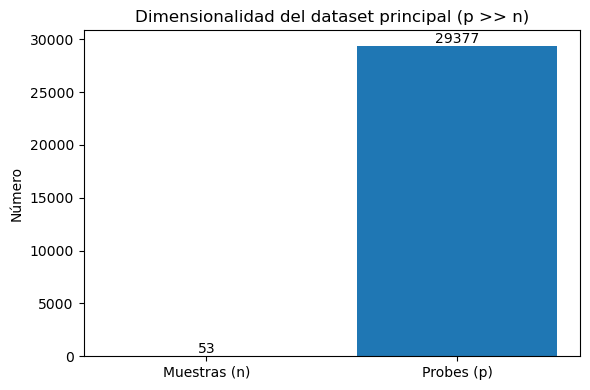


=== RESULTADOS EXPERIMENTO K ===


,Model,K,ROC-AUC,ROC-AUC std,F1,Accuracy,Sensitivity,Specificity,Precision,Recall,Balanced Acc,MCC,TP,TN,FP,FN,Time (s)
0,LR + MutualInfo,20,0.903333,0.066999,0.727778,0.754545,0.739130,0.766667,0.708333,0.739130,0.752899,0.503612,17,23,7,6,236.446182
1,LR + ANOVA,20,0.896667,0.113725,0.822222,0.829091,0.826087,0.833333,0.791667,0.826087,0.829710,0.656572,19,25,5,4,3.850197
2,LR + ANOVA,50,0.860000,0.123648,0.733333,0.756364,0.739130,0.766667,0.708333,0.739130,0.752899,0.503612,17,23,7,6,3.614005
3,LR + MutualInfo,50,0.855000,0.102144,0.694488,0.734545,0.695652,0.766667,0.695652,0.695652,0.731159,0.462319,16,23,7,7,238.642556
4,LR + ANOVA,100,0.831667,0.143798,0.644444,0.678182,0.652174,0.700000,0.625000,0.652174,0.676087,0.350653,15,21,9,8,3.387236
5,LR + MutualInfo,100,0.825000,0.131445,0.696869,0.734545,0.695652,0.766667,0.695652,0.695652,0.731159,0.462319,16,23,7,7,234.270360
6,LR + RFE,50,0.816667,0.144530,0.620000,0.658182,0.652174,0.666667,0.600000,0.652174,0.659420,0.316555,15,20,10,8,234.982060
7,LR + RFE,20,0.798333,0.090123,0.659091,0.714545,0.608696,0.800000,0.700000,0.608696,0.704348,0.417881,14,24,6,9,241.124528
8,LR baseline,20,0.790000,0.156915,0.677778,0.696364,0.695652,0.700000,0.640000,0.695652,0.697826,0.392816,16,21,9,7,5.886521
9,LR baseline,50,0.790000,0.156915,0.677778,0.696364,0.695652,0.700000,0.640000,0.695652,0.697826,0.392816,16,21,9,7,4.386322



=== RESULTADOS EXPERIMENTO L1 ===


,Model,C,ROC-AUC,ROC-AUC std,F1,Accuracy,Sensitivity,Specificity,Precision,Recall,Balanced Acc,MCC,TP,TN,FP,FN,Time (s)
0,LR L1,0.10,0.958333,0.038730,0.837778,0.869091,0.782609,0.933333,0.900000,0.782609,0.857971,0.732033,18,28,2,5,347.959948
1,LR L1,1.00,0.820000,0.132665,0.731111,0.732727,0.782609,0.700000,0.666667,0.782609,0.741304,0.478466,18,21,9,5,409.446759
2,LR L1,0.01,0.500000,0.000000,0.000000,0.567273,0.000000,1.000000,0.000000,0.000000,0.500000,0.000000,0,30,0,23,3.652152



=== RESULTADOS INTERNOS COMBINADOS ===


,Model_label,ROC-AUC,ROC-AUC std,F1,Accuracy,Sensitivity,Specificity,Precision,Recall,Balanced Acc,MCC,TP,TN,FP,FN,Time (s)
0,LR L1 | C=0.1,0.958333,0.038730,0.837778,0.869091,0.782609,0.933333,0.900000,0.782609,0.857971,0.732033,18,28,2,5,347.959948
1,LR + MutualInfo | K=20,0.903333,0.066999,0.727778,0.754545,0.739130,0.766667,0.708333,0.739130,0.752899,0.503612,17,23,7,6,236.446182
2,LR + ANOVA | K=20,0.896667,0.113725,0.822222,0.829091,0.826087,0.833333,0.791667,0.826087,0.829710,0.656572,19,25,5,4,3.850197
3,LR + ANOVA | K=50,0.860000,0.123648,0.733333,0.756364,0.739130,0.766667,0.708333,0.739130,0.752899,0.503612,17,23,7,6,3.614005
4,LR + MutualInfo | K=50,0.855000,0.102144,0.694488,0.734545,0.695652,0.766667,0.695652,0.695652,0.731159,0.462319,16,23,7,7,238.642556
5,LR + ANOVA | K=100,0.831667,0.143798,0.644444,0.678182,0.652174,0.700000,0.625000,0.652174,0.676087,0.350653,15,21,9,8,3.387236
6,LR + MutualInfo | K=100,0.825000,0.131445,0.696869,0.734545,0.695652,0.766667,0.695652,0.695652,0.731159,0.462319,16,23,7,7,234.270360
7,LR L1 | C=1.0,0.820000,0.132665,0.731111,0.732727,0.782609,0.700000,0.666667,0.782609,0.741304,0.478466,18,21,9,5,409.446759
8,LR + RFE | K=50,0.816667,0.144530,0.620000,0.658182,0.652174,0.666667,0.600000,0.652174,0.659420,0.316555,15,20,10,8,234.982060
9,LR + RFE | K=20,0.798333,0.090123,0.659091,0.714545,0.608696,0.800000,0.700000,0.608696,0.704348,0.417881,14,24,6,9,241.124528


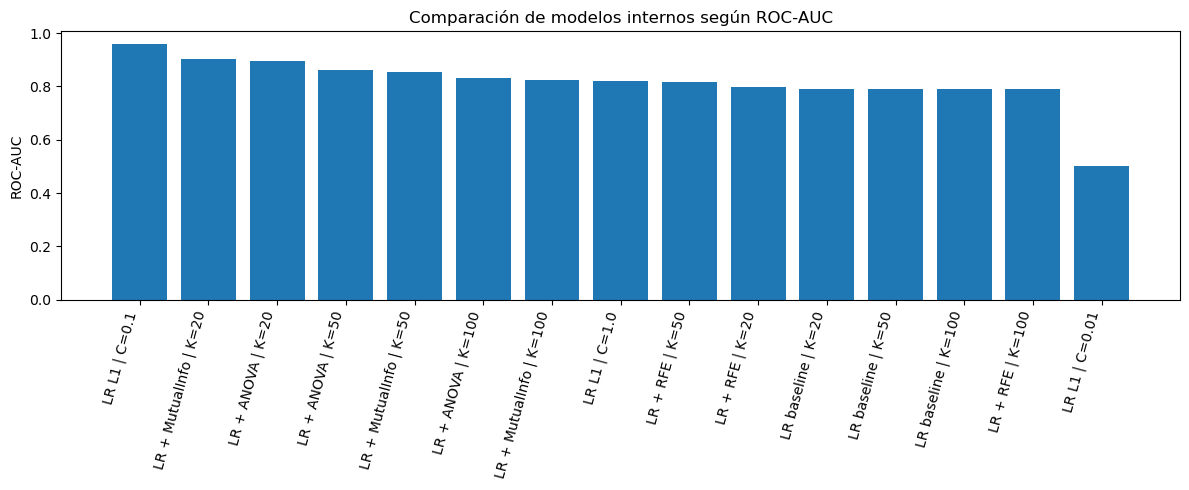

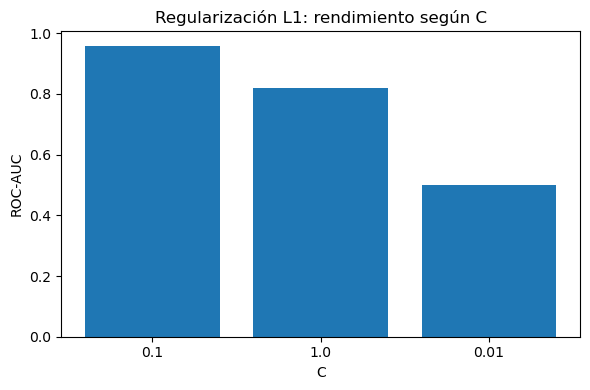

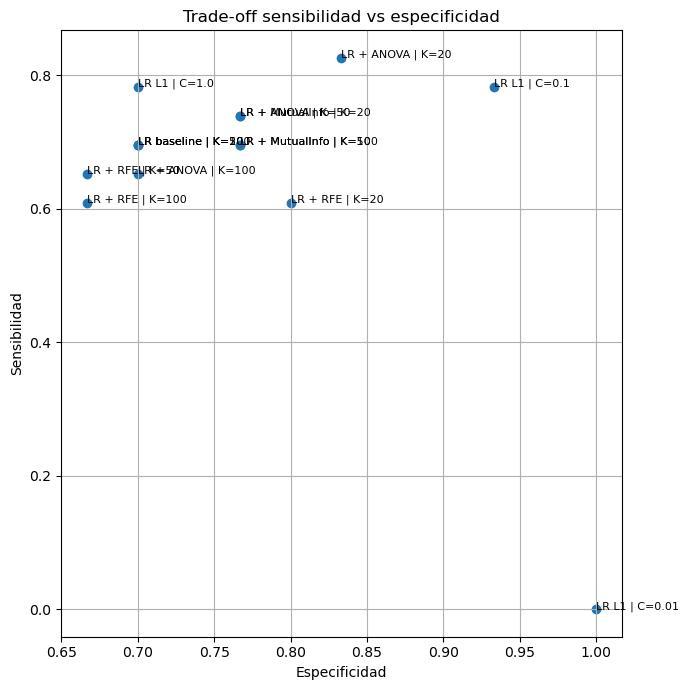

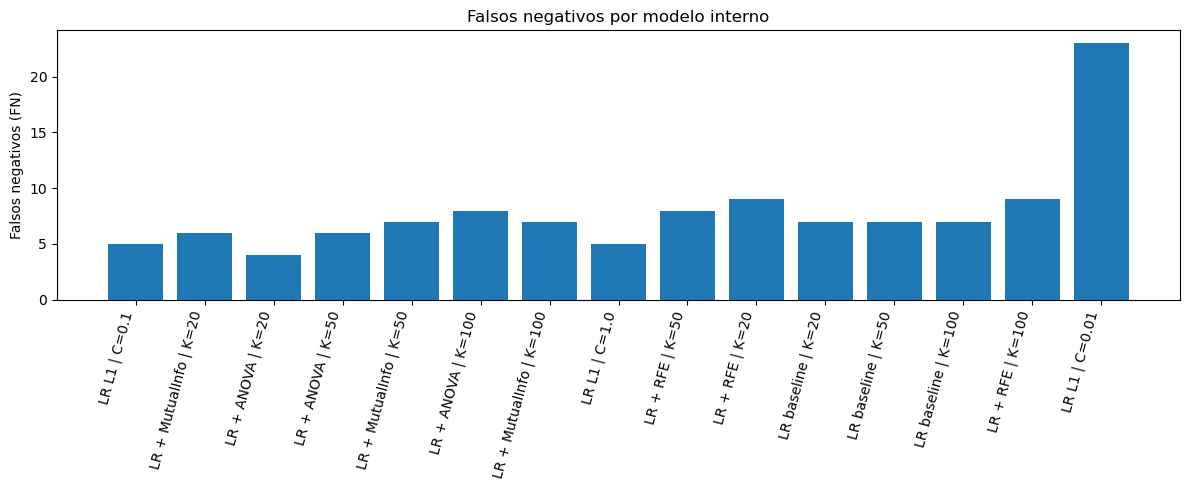


=== CURVAS ROC VALIDACIÓN EXTERNA ===
Estrategia externa seleccionada: Raw log2


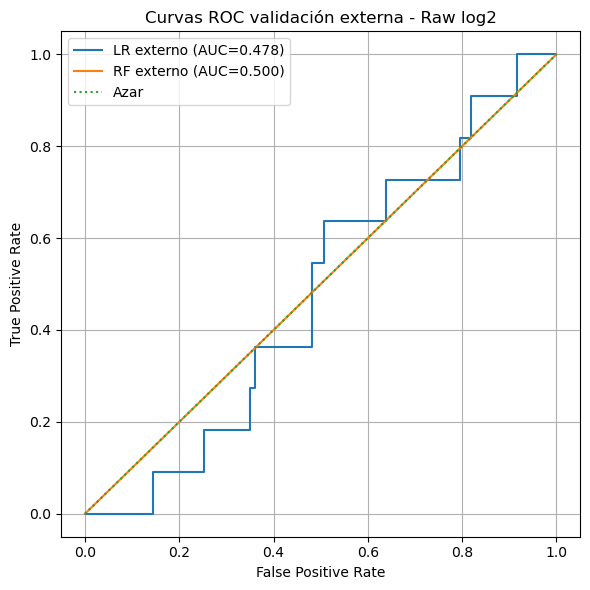

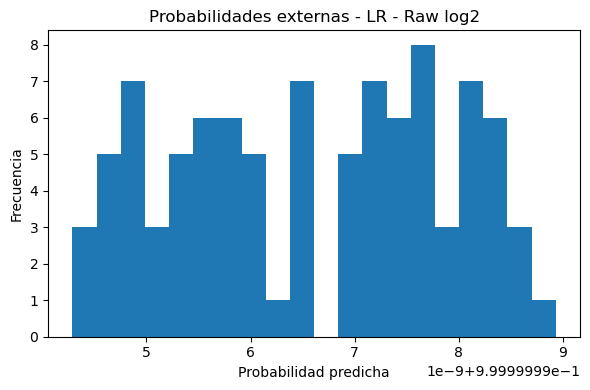

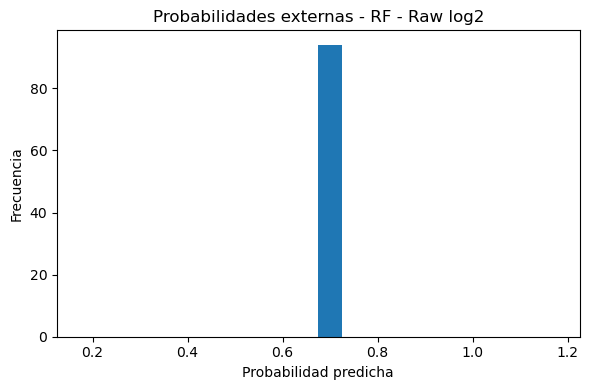


=== HEATMAP FIRMA L1 ===


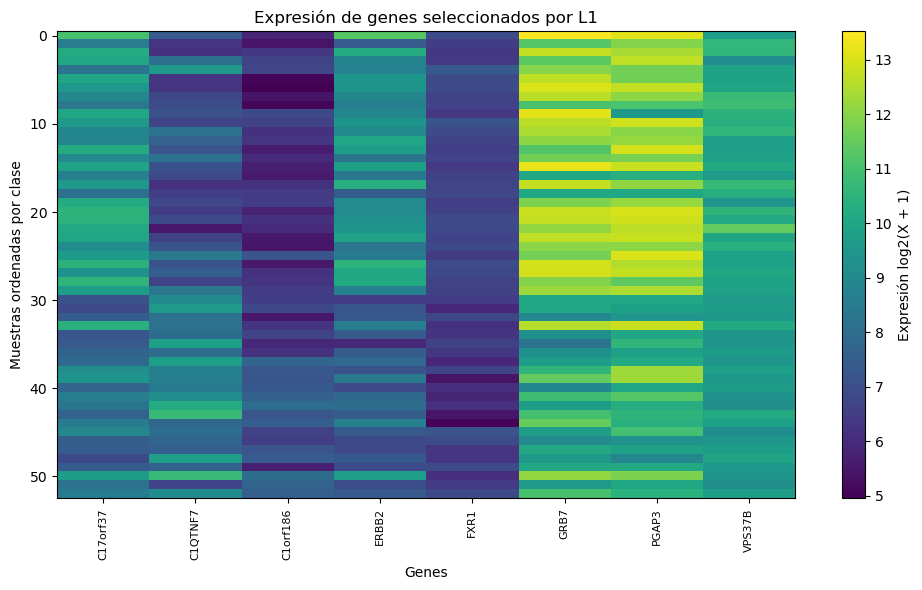


=== IMPORTANCIA FIRMA L1 ===


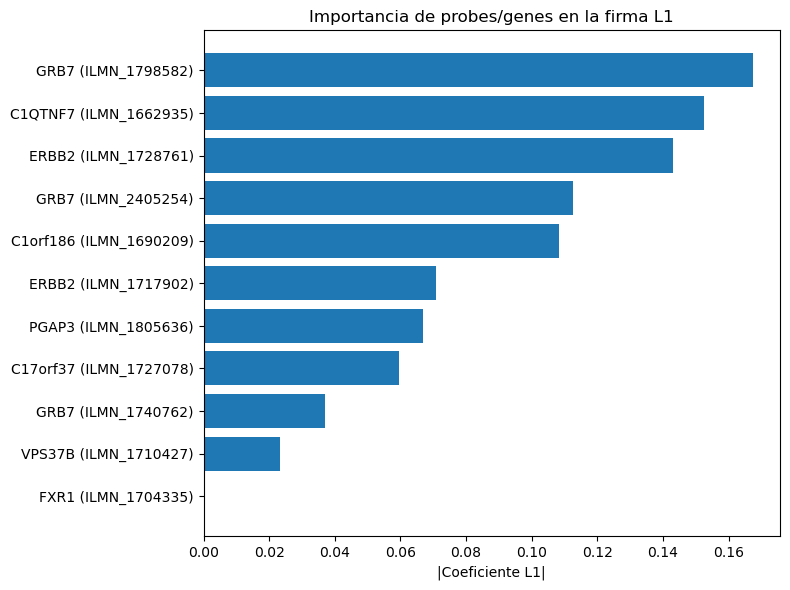

,Probe,Gene,Coefficient,Abs coefficient
0,ILMN_1798582,GRB7,-0.167292,0.167292
1,ILMN_1662935,C1QTNF7,0.152422,0.152422
2,ILMN_1728761,ERBB2,-0.142938,0.142938
3,ILMN_2405254,GRB7,-0.112535,0.112535
4,ILMN_1690209,C1orf186,0.108403,0.108403
5,ILMN_1717902,ERBB2,-0.070808,0.070808
6,ILMN_1805636,PGAP3,-0.066866,0.066866
7,ILMN_1727078,C17orf37,-0.059403,0.059403
8,ILMN_1740762,GRB7,-0.037005,0.037005
9,ILMN_1710427,VPS37B,-0.023364,0.023364



=== ESTABILIDAD DE GENES ===


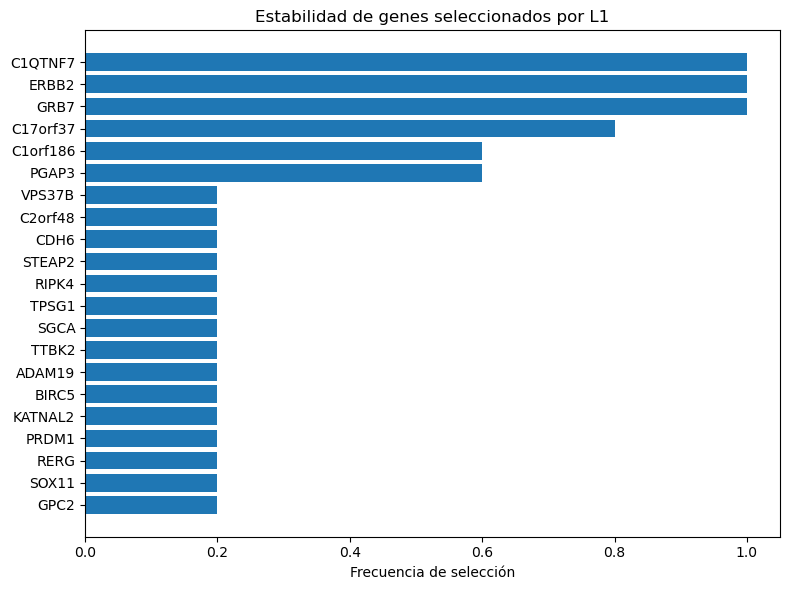

,Gene,Selection count,Selection frequency
0,C1QTNF7,5,1.0
1,ERBB2,5,1.0
2,GRB7,5,1.0
3,C17orf37,4,0.8
4,C1orf186,3,0.6
5,PGAP3,3,0.6
6,C2orf48,1,0.2
7,CDH6,1,0.2
8,STEAP2,1,0.2
9,VPS37B,1,0.2



=== RESUMEN VALIDACIÓN EXTERNA ===


,Model,AUC,AUC inverted,Best threshold,N unique probabilities,Prob min,Prob max,Prob mean,Prob std,Sensitivity,Specificity,Precision,Balanced Acc,MCC,TP,TN,FP,FN
0,RF | Raw log2,0.500000,0.500000,inf,1,0.675000,0.675000,0.675000,3.330669e-16,0.000000,1.000000,0.000000,0.500000,0.000000,0,83,0,11
1,LR | Raw log2,0.477547,0.522453,1.000000,1,1.000000,1.000000,1.000000,1.272760e-09,0.636364,0.493976,0.142857,0.565170,0.083870,7,41,42,4
2,LR | Sample rank,0.464403,0.535597,0.001633,23,0.000323,0.377532,0.034761,7.290820e-02,1.000000,0.060241,0.123596,0.530120,0.086287,11,5,78,0
3,RF | Sample rank,0.461117,0.538883,0.646273,20,0.024515,0.646273,0.317359,2.655816e-01,0.090909,0.939759,0.166667,0.515334,0.040328,1,78,5,10
4,LR | Sample z-score,0.452355,0.547645,0.001018,90,0.000052,0.416943,0.007439,4.328400e-02,0.454545,0.638554,0.142857,0.546550,0.061905,5,53,30,6
5,RF | Sample z-score,0.393209,0.606791,0.680000,45,0.105000,0.705000,0.282713,1.566567e-01,0.090909,0.975904,0.333333,0.533406,0.122184,1,81,2,10



=== THRESHOLDS VALIDACIÓN EXTERNA ===


,Model,Threshold,Sensitivity,Specificity,Precision,Balanced Acc,MCC,TP,TN,FP,FN
0,LR | Raw log2,0.2,1.000000,0.000000,0.117021,0.500000,0.000000,11,0,83,0
1,LR | Raw log2,0.3,1.000000,0.000000,0.117021,0.500000,0.000000,11,0,83,0
2,LR | Raw log2,0.4,1.000000,0.000000,0.117021,0.500000,0.000000,11,0,83,0
3,LR | Raw log2,0.5,1.000000,0.000000,0.117021,0.500000,0.000000,11,0,83,0
4,RF | Raw log2,0.2,1.000000,0.000000,0.117021,0.500000,0.000000,11,0,83,0
5,RF | Raw log2,0.3,1.000000,0.000000,0.117021,0.500000,0.000000,11,0,83,0
6,RF | Raw log2,0.4,1.000000,0.000000,0.117021,0.500000,0.000000,11,0,83,0
7,RF | Raw log2,0.5,1.000000,0.000000,0.117021,0.500000,0.000000,11,0,83,0
8,LR | Sample z-score,0.2,0.000000,0.987952,0.000000,0.493976,-0.037750,0,82,1,11
9,LR | Sample z-score,0.3,0.000000,0.987952,0.000000,0.493976,-0.037750,0,82,1,11



=== FIN BLOQUE E ===


In [5]:
# ============================================================
# E: VISUALIZACIÓN FINAL
# ============================================================

print("\n" + "=" * 60)
print("=== E: VISUALIZACIÓN FINAL ===")
print("=" * 60)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score


# ------------------------------------------------------------
# E1. Dimensionalidad p >> n
# ------------------------------------------------------------

n_samples = X_log.shape[0]
n_features = X_log.shape[1]

print("n muestras:", n_samples)
print("p genes/probes:", n_features)

plt.figure(figsize=(6, 4))
plt.bar(["Muestras (n)", "Probes (p)"], [n_samples, n_features])
plt.title("Dimensionalidad del dataset principal (p >> n)")
plt.ylabel("Número")

for i, v in enumerate([n_samples, n_features]):
    plt.text(i, v + (0.01 * n_features), str(v), ha="center")

plt.tight_layout()
plt.savefig("fig_p_vs_n_gse55348.png", dpi=300)
plt.show()


# ------------------------------------------------------------
# E2. Tablas de resultados internos
# ------------------------------------------------------------

print("\n=== RESULTADOS EXPERIMENTO K ===")

results_df = pd.DataFrame(all_results).sort_values(
    by=["ROC-AUC", "MCC"],
    ascending=False
).reset_index(drop=True)

display(results_df)


print("\n=== RESULTADOS EXPERIMENTO L1 ===")

l1_results_df = pd.DataFrame(l1_results).sort_values(
    by=["ROC-AUC", "MCC"],
    ascending=False
).reset_index(drop=True)

display(l1_results_df)


# ------------------------------------------------------------
# E3. Tabla combinada para visualización interna
# ------------------------------------------------------------

results_plot_df = results_df.copy()
results_plot_df["Model_label"] = (
    results_plot_df["Model"] + " | K=" + results_plot_df["K"].astype(str)
)

l1_plot_df = l1_results_df.copy()
l1_plot_df["Model_label"] = (
    l1_plot_df["Model"] + " | C=" + l1_plot_df["C"].astype(str)
)

common_cols = [
    "Model_label",
    "ROC-AUC",
    "ROC-AUC std",
    "F1",
    "Accuracy",
    "Sensitivity",
    "Specificity",
    "Precision",
    "Recall",
    "Balanced Acc",
    "MCC",
    "TP",
    "TN",
    "FP",
    "FN",
    "Time (s)"
]

combined_results_df = pd.concat(
    [
        results_plot_df[common_cols],
        l1_plot_df[common_cols]
    ],
    ignore_index=True
)

combined_results_df = combined_results_df.sort_values(
    by=["ROC-AUC", "MCC"],
    ascending=False
).reset_index(drop=True)

print("\n=== RESULTADOS INTERNOS COMBINADOS ===")
display(combined_results_df)


# ------------------------------------------------------------
# E4. Comparación ROC-AUC modelos internos
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))
plt.bar(combined_results_df["Model_label"], combined_results_df["ROC-AUC"])

plt.xticks(rotation=75, ha="right")
plt.ylabel("ROC-AUC")
plt.title("Comparación de modelos internos según ROC-AUC")

plt.tight_layout()
plt.savefig("fig_auc_modelos_internos.png", dpi=300)
plt.show()


# ------------------------------------------------------------
# E5. Comparación L1 por C
# ------------------------------------------------------------

plt.figure(figsize=(6, 4))
plt.bar(l1_results_df["C"].astype(str), l1_results_df["ROC-AUC"])

plt.xlabel("C")
plt.ylabel("ROC-AUC")
plt.title("Regularización L1: rendimiento según C")

plt.tight_layout()
plt.savefig("fig_l1_auc_por_c.png", dpi=300)
plt.show()


# ------------------------------------------------------------
# E6. Sensibilidad vs especificidad
# ------------------------------------------------------------

plt.figure(figsize=(7, 7))
plt.scatter(combined_results_df["Specificity"], combined_results_df["Sensitivity"])

for _, row in combined_results_df.iterrows():
    plt.text(
        row["Specificity"],
        row["Sensitivity"],
        row["Model_label"],
        fontsize=8
    )

plt.xlabel("Especificidad")
plt.ylabel("Sensibilidad")
plt.title("Trade-off sensibilidad vs especificidad")
plt.grid()

plt.tight_layout()
plt.savefig("fig_sens_vs_spec_modelos_internos.png", dpi=300)
plt.show()


# ------------------------------------------------------------
# E7. Falsos negativos por modelo
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))
plt.bar(combined_results_df["Model_label"], combined_results_df["FN"])

plt.xticks(rotation=75, ha="right")
plt.ylabel("Falsos negativos (FN)")
plt.title("Falsos negativos por modelo interno")

plt.tight_layout()
plt.savefig("fig_fn_modelos_internos.png", dpi=300)
plt.show()


# ------------------------------------------------------------
# E8. Curvas ROC validación externa GSE58984
# ------------------------------------------------------------

print("\n=== CURVAS ROC VALIDACIÓN EXTERNA ===")
print("Estrategia externa seleccionada:", best_strategy)

fpr_lr, tpr_lr, _ = roc_curve(y_58984, y_prob_lr)
auc_lr = roc_auc_score(y_58984, y_prob_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_58984, y_prob_rf)
auc_rf = roc_auc_score(y_58984, y_prob_rf)

plt.figure(figsize=(6, 6))

plt.plot(fpr_lr, tpr_lr, label=f"LR externo (AUC={auc_lr:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"RF externo (AUC={auc_rf:.3f})")
plt.plot([0, 1], [0, 1], linestyle=":", label="Azar")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Curvas ROC validación externa - {best_strategy}")
plt.legend()
plt.grid()

plt.tight_layout()
plt.savefig("fig_roc_validacion_externa.png", dpi=300)
plt.show()


# ------------------------------------------------------------
# E9. Distribución de probabilidades externas
# ------------------------------------------------------------

plt.figure(figsize=(6, 4))
plt.hist(y_prob_lr, bins=20)

plt.title(f"Probabilidades externas - LR - {best_strategy}")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.savefig("fig_prob_dist_lr_externa.png", dpi=300)
plt.show()


plt.figure(figsize=(6, 4))
plt.hist(y_prob_rf, bins=20)

plt.title(f"Probabilidades externas - RF - {best_strategy}")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.savefig("fig_prob_dist_rf_externa.png", dpi=300)
plt.show()


# ------------------------------------------------------------
# E10. Heatmap firma L1
# ------------------------------------------------------------

print("\n=== HEATMAP FIRMA L1 ===")

probe_to_gene_final = dict(
    zip(signature_l1_df["Probe"], signature_l1_df["Gene"])
)

X_selected = X_log[list(signature_l1_df["Probe"])].copy()
X_selected = X_selected.rename(columns=probe_to_gene_final)
X_selected = X_selected.T.groupby(level=0).mean().T

df_plot = X_selected.copy()
df_plot["label"] = y
df_plot = df_plot.sort_values("label")

plt.figure(figsize=(10, 6))

plt.imshow(
    df_plot.drop(columns="label").values,
    aspect="auto",
    interpolation="nearest"
)

plt.colorbar(label="Expresión log2(X + 1)")
plt.title("Expresión de genes seleccionados por L1")
plt.xlabel("Genes")
plt.ylabel("Muestras ordenadas por clase")

plt.xticks(
    ticks=np.arange(len(df_plot.drop(columns="label").columns)),
    labels=df_plot.drop(columns="label").columns,
    rotation=90,
    fontsize=8
)

plt.tight_layout()
plt.savefig("fig_heatmap_firma_l1.png", dpi=300)
plt.show()


# ------------------------------------------------------------
# E11. Importancia de genes por coeficiente L1
# ------------------------------------------------------------

print("\n=== IMPORTANCIA FIRMA L1 ===")

signature_plot_df = signature_l1_df.copy()
signature_plot_df = signature_plot_df.sort_values(
    by="Abs coefficient",
    ascending=True
)

plt.figure(figsize=(8, 6))

plt.barh(
    signature_plot_df["Gene"] + " (" + signature_plot_df["Probe"] + ")",
    signature_plot_df["Abs coefficient"]
)

plt.xlabel("|Coeficiente L1|")
plt.title("Importancia de probes/genes en la firma L1")

plt.tight_layout()
plt.savefig("fig_importancia_firma_l1.png", dpi=300)
plt.show()

display(signature_l1_df)


# ------------------------------------------------------------
# E12. Estabilidad de genes
# ------------------------------------------------------------

print("\n=== ESTABILIDAD DE GENES ===")

gene_plot_df = gene_stability_df.copy()
gene_plot_df = gene_plot_df.sort_values(
    by="Selection frequency",
    ascending=True
)

plt.figure(figsize=(8, 6))

plt.barh(
    gene_plot_df["Gene"],
    gene_plot_df["Selection frequency"]
)

plt.xlabel("Frecuencia de selección")
plt.title("Estabilidad de genes seleccionados por L1")

plt.tight_layout()
plt.savefig("fig_estabilidad_genes_l1.png", dpi=300)
plt.show()

display(gene_stability_df)


# ------------------------------------------------------------
# E13. Resultados validación externa
# ------------------------------------------------------------

print("\n=== RESUMEN VALIDACIÓN EXTERNA ===")

display(external_results_df)

print("\n=== THRESHOLDS VALIDACIÓN EXTERNA ===")

display(external_thresholds_df)


print("\n=== FIN BLOQUE E ===")